### Importing necessary Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load the dataset

In [5]:
df = pd.read_csv(r'D:\Covid-19-Mexico-Dataset-Analysis\Data/CovidData.csv')
df.head(10)

,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,...,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
0,2,1,1,1,03/05/2020,97,1,65,2,2,...,2,2,1,2,2,2,2,2,3,97
1,2,1,2,1,03/06/2020,97,1,72,97,2,...,2,2,1,2,2,1,1,2,5,97
2,2,1,2,2,09/06/2020,1,2,55,97,1,...,2,2,2,2,2,2,2,2,3,2
3,2,1,1,1,12/06/2020,97,2,53,2,2,...,2,2,2,2,2,2,2,2,7,97
4,2,1,2,1,21/06/2020,97,2,68,97,1,...,2,2,1,2,2,2,2,2,3,97
5,2,1,1,2,9999-99-99,2,1,40,2,2,...,2,2,2,2,2,2,2,2,3,2
6,2,1,1,1,9999-99-99,97,2,64,2,2,...,2,2,2,2,2,2,2,2,3,97
7,2,1,1,1,9999-99-99,97,1,64,2,1,...,2,1,1,2,2,2,1,2,3,97
8,2,1,1,2,9999-99-99,2,2,37,2,1,...,2,2,1,2,2,1,2,2,3,2
9,2,1,1,2,9999-99-99,2,2,25,2,2,...,2,2,2,2,2,2,2,2,3,2


In [6]:
df.tail()

,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,...,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
1048570,2,13,2,1,9999-99-99,97,2,40,97,2,...,2,2,2,2,2,2,2,2,7,97
1048571,1,13,2,2,9999-99-99,2,2,51,97,2,...,2,2,1,2,2,2,2,2,7,2
1048572,2,13,2,1,9999-99-99,97,2,55,97,2,...,2,2,2,2,2,2,2,2,7,97
1048573,2,13,2,1,9999-99-99,97,2,28,97,2,...,2,2,2,2,2,2,2,2,7,97
1048574,2,13,2,1,9999-99-99,97,2,52,97,2,...,2,2,2,2,2,2,2,2,7,97


### Basic information about the Dataset:
+ Contains a vast number of anonymized patient-related information including pre-conditions. The raw dataset consists of 21 different features and 1,048,576 unique patients. In the Boolean features, 1 means "yes" and 2 means "no". values as 97 and 99 are missing data.

In [7]:
df.shape

(1048575, 21)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 21 columns):
 #   Column                Non-Null Count    Dtype
---  ------                --------------    -----
 0   USMER                 1048575 non-null  int64
 1   MEDICAL_UNIT          1048575 non-null  int64
 2   SEX                   1048575 non-null  int64
 3   PATIENT_TYPE          1048575 non-null  int64
 4   DATE_DIED             1048575 non-null  str  
 5   INTUBED               1048575 non-null  int64
 6   PNEUMONIA             1048575 non-null  int64
 7   AGE                   1048575 non-null  int64
 8   PREGNANT              1048575 non-null  int64
 9   DIABETES              1048575 non-null  int64
 10  COPD                  1048575 non-null  int64
 11  ASTHMA                1048575 non-null  int64
 12  INMSUPR               1048575 non-null  int64
 13  HIPERTENSION          1048575 non-null  int64
 14  OTHER_DISEASE         1048575 non-null  int64
 15  CARDIOVASCULAR        1048

In [9]:
df.describe()

,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,COPD,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,1.632194e+00,8.980565e+00,1.499259e+00,1.190765e+00,7.952288e+01,3.346831e+00,4.179410e+01,4.976558e+01,2.186404e+00,2.260569e+00,2.242626e+00,2.298132e+00,2.128989e+00,2.435143e+00,2.261810e+00,2.125176e+00,2.257180e+00,2.214333e+00,5.305653e+00,7.955397e+01
std,4.822084e-01,3.723278e+00,4.999997e-01,3.929041e-01,3.686889e+01,1.191288e+01,1.690739e+01,4.751073e+01,5.424242e+00,5.132258e+00,5.114089e+00,5.462843e+00,5.236397e+00,6.646676e+00,5.194850e+00,5.175445e+00,5.135354e+00,5.323097e+00,1.881165e+00,3.682307e+01
min,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
25%,1.000000e+00,4.000000e+00,1.000000e+00,1.000000e+00,9.700000e+01,2.000000e+00,3.000000e+01,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00,9.700000e+01
50%,2.000000e+00,1.200000e+01,1.000000e+00,1.000000e+00,9.700000e+01,2.000000e+00,4.000000e+01,9.700000e+01,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,6.000000e+00,9.700000e+01
75%,2.000000e+00,1.200000e+01,2.000000e+00,1.000000e+00,9.700000e+01,2.000000e+00,5.300000e+01,9.700000e+01,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,7.000000e+00,9.700000e+01
max,2.000000e+00,1.300000e+01,2.000000e+00,2.000000e+00,9.900000e+01,9.900000e+01,1.210000e+02,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,7.000000e+00,9.900000e+01


In [10]:
df.isna().sum()

USMER                   0
MEDICAL_UNIT            0
SEX                     0
PATIENT_TYPE            0
DATE_DIED               0
INTUBED                 0
PNEUMONIA               0
AGE                     0
PREGNANT                0
DIABETES                0
COPD                    0
ASTHMA                  0
INMSUPR                 0
HIPERTENSION            0
OTHER_DISEASE           0
CARDIOVASCULAR          0
OBESITY                 0
RENAL_CHRONIC           0
TOBACCO                 0
CLASIFFICATION_FINAL    0
ICU                     0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(812049)

In [12]:
# df.drop_duplicates(inplace=True)

In [13]:
df.isnull().sum()

USMER                   0
MEDICAL_UNIT            0
SEX                     0
PATIENT_TYPE            0
DATE_DIED               0
INTUBED                 0
PNEUMONIA               0
AGE                     0
PREGNANT                0
DIABETES                0
COPD                    0
ASTHMA                  0
INMSUPR                 0
HIPERTENSION            0
OTHER_DISEASE           0
CARDIOVASCULAR          0
OBESITY                 0
RENAL_CHRONIC           0
TOBACCO                 0
CLASIFFICATION_FINAL    0
ICU                     0
dtype: int64

--------------------
--------------------

### Problem Statement
+ To develop an Artificial Neural Network capable of predicting patient mortality risk based on demographic data, pre-existing medical conditions, and hospitalization metrics. This predictive model aims to assist healthcare professionals in the early identification of high-risk patients, enabling better triaging, resource allocation, and proactive medical intervention.

In [14]:
df['DIED'] = (df['DATE_DIED'] != '9999-99-99').astype(int)

In [15]:
df.drop(columns=['DATE_DIED'], inplace=True)

In [16]:
print(df['DIED'].value_counts())

DIED
0    971633
1     76942
Name: count, dtype: int64


### Observation:
+ severe class imbalance

------------
------------

In [17]:
# 1. Define the specific list of columns where '2' means 'No'
medical_conditions = [
    'PNEUMONIA', 'PREGNANT', 'DIABETES', 'COPD', 'ASTHMA', 'INMSUPR', 
    'HIPERTENSION', 'OTHER_DISEASE', 'CARDIOVASCULAR', 'OBESITY', 
    'RENAL_CHRONIC', 'TOBACCO', 'INTUBED', 'ICU'
]

# 2. Apply the replace function ONLY to these specific columns
# We replace 2 (No) with 0 (No)
df[medical_conditions] = df[medical_conditions].replace(2, 0)

# 3. Verify the change by checking one of the columns (e.g., DIABETES)
print("DIABETES value counts after replacement:")
print(df['DIABETES'].value_counts())

DIABETES value counts after replacement:
DIABETES
0     920248
1     124989
98      3338
Name: count, dtype: int64


In [18]:
print(df['DIABETES'].value_counts(normalize=True))

DIABETES
0     0.877618
1     0.119199
98    0.003183
Name: proportion, dtype: float64


In [19]:
# 1. Define the missing value placeholders
missing_flags = [97, 98, 99]

# 2. Replace these specific numbers with standard pandas NaN across the whole dataframe
df.replace(missing_flags, np.nan, inplace=True)

# 3. Calculate the percentage of missing data in each column
missing_report = (df.isnull().sum() / len(df)) * 100

# 4. Print the report, sorting from highest missing percentage to lowest
print("--- Missing Data Report (%) ---")
print(missing_report.sort_values(ascending=False))

--- Missing Data Report (%) ---
ICU                     81.637651
INTUBED                 81.622106
PREGNANT                50.283957
PNEUMONIA                1.526166
OTHER_DISEASE            0.481129
INMSUPR                  0.324631
DIABETES                 0.318337
TOBACCO                  0.307083
HIPERTENSION             0.296021
CARDIOVASCULAR           0.293350
OBESITY                  0.289154
RENAL_CHRONIC            0.286675
COPD                     0.286389
ASTHMA                   0.284100
AGE                      0.032902
MEDICAL_UNIT             0.000000
USMER                    0.000000
PATIENT_TYPE             0.000000
SEX                      0.000000
CLASIFFICATION_FINAL     0.000000
DIED                     0.000000
dtype: float64


In [20]:
# 1. Drop the columns that are mostly missing data
columns_to_drop = ['INTUBED', 'ICU', 'PREGNANT']
df.drop(columns=columns_to_drop, inplace=True)

# 2. Drop any remaining patient rows that have NaN values (the ~0.3%)
df.dropna(inplace=True)

# 3. Verify our final, clean dataset shape
print("Final clean dataset shape:", df.shape)
print("Remaining Missing Values:\n", df.isnull().sum().sum())

Final clean dataset shape: (1024829, 18)
Remaining Missing Values:
 0


In [21]:
# 'Data/' inside the notebook is the direct bridge to your Windows D:\...\Data folder
save_path = 'D:\Covid-19-Mexico-Dataset-Analysis\Data/Cleaned_CovidData.csv'

# Export the dataframe
df.to_csv(save_path, index=False)

print("Success! File exported.")
print("It is physically saved on your Windows machine at: D:\\Covid-19-Mexico-Dataset-Analysis\\Data\\Cleaned_CovidData.csv")

<>:2: SyntaxWarning: invalid escape sequence '\C'
<>:2: SyntaxWarning: invalid escape sequence '\C'
C:\Users\rohit\AppData\Local\Temp\ipykernel_33964\971944015.py:2: SyntaxWarning: invalid escape sequence '\C'
  save_path = 'D:\Covid-19-Mexico-Dataset-Analysis\Data/Cleaned_CovidData.csv'


Success! File exported.
It is physically saved on your Windows machine at: D:\Covid-19-Mexico-Dataset-Analysis\Data\Cleaned_CovidData.csv


------------
------------

### Analysis Part Starts from here.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Loading the dataset

In [2]:
df = pd.read_csv('Data/Cleaned_CovidData.csv')
df.head()

,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,PNEUMONIA,AGE,DIABETES,COPD,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,DIED
0,2,1,1,1,1.0,65.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3,1
1,2,1,2,1,1.0,72.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,5,1
2,2,1,2,2,0.0,55.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,1
3,2,1,1,1,0.0,53.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7,1
4,2,1,2,1,0.0,68.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3,1


In [3]:
df.shape

(1024829, 18)

In [4]:
df.columns

Index(['USMER', 'MEDICAL_UNIT', 'SEX', 'PATIENT_TYPE', 'PNEUMONIA', 'AGE',
       'DIABETES', 'COPD', 'ASTHMA', 'INMSUPR', 'HIPERTENSION',
       'OTHER_DISEASE', 'CARDIOVASCULAR', 'OBESITY', 'RENAL_CHRONIC',
       'TOBACCO', 'CLASIFFICATION_FINAL', 'DIED'],
      dtype='str')

/tmp/ipykernel_9/1969792172.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='DIED', palette=['#2ECC71', '#E74C3C'])


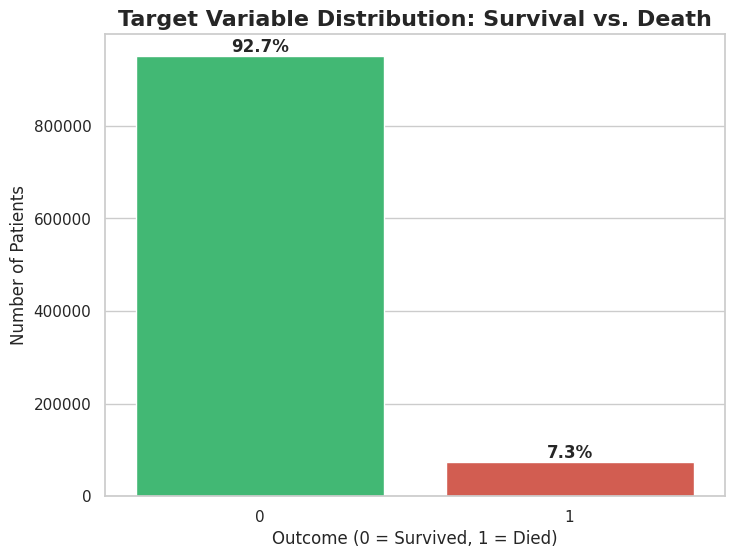

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set a professional visual style
sns.set_theme(style="whitegrid")

# 2. Create the canvas size
plt.figure(figsize=(8, 6))

# 3. Plot the bar chart using our 'DIED' column
# We use Green (#2ECC71) for Survived (0) and Red (#E74C3C) for Died (1)
ax = sns.countplot(data=df, x='DIED', palette=['#2ECC71', '#E74C3C'])

# 4. Add professional titles and labels
plt.title('Target Variable Distribution: Survival vs. Death', fontsize=16, fontweight='bold')
plt.xlabel('Outcome (0 = Survived, 1 = Died)', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)

# 5. Calculate and display the exact percentages on top of the bars
total = len(df)
for p in ax.patches:
    height = p.get_height()
    percentage = f'{100 * height / total:.1f}%'
    ax.annotate(percentage, 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', 
                fontsize=12, fontweight='bold')

# 6. Render the plot
plt.show()

/tmp/ipykernel_9/475641772.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.countplot(data=df, x='SEX', palette='Set2', ax=axes[1])


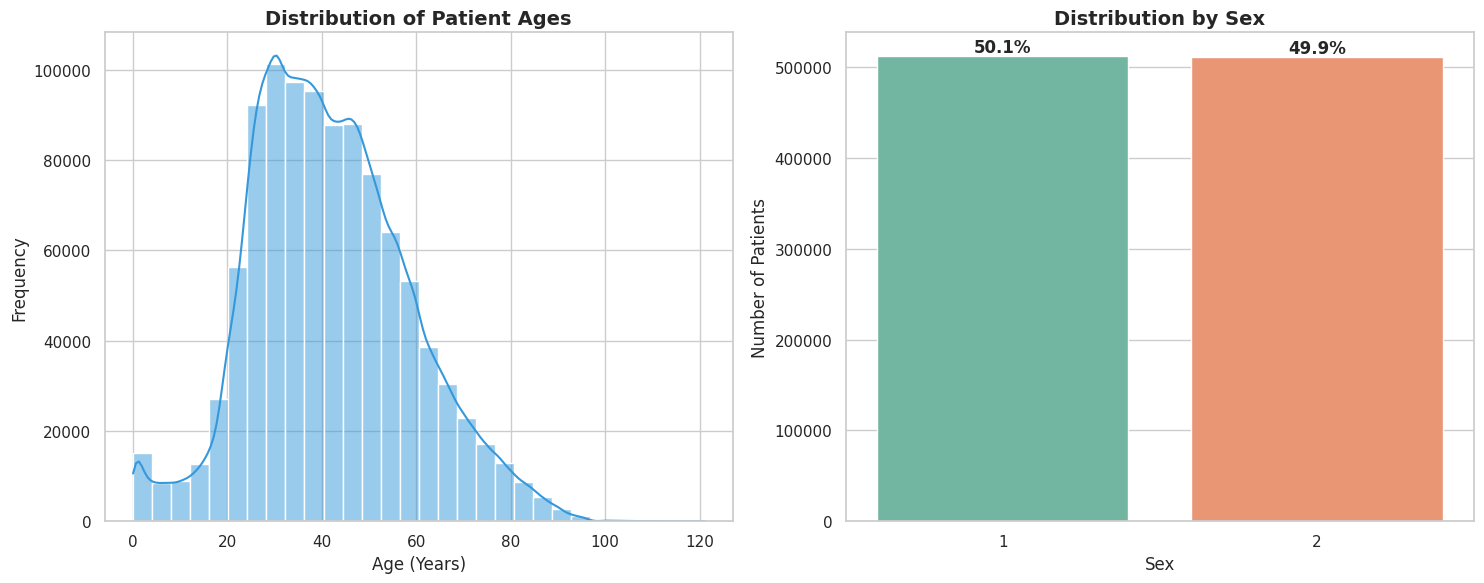

In [ ]:
# Set visual style
sns.set_theme(style="whitegrid")

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Plot 1: Age Distribution (Continuous) ---
sns.histplot(data=df, x='AGE', bins=30, kde=True, color='#3498DB', ax=axes[0])
axes[0].set_title('Distribution of Patient Ages', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age (Years)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)

# --- Plot 2: Sex Distribution (Categorical) ---
# Assuming 'SEX' is encoded as 1 (e.g., Female) and 2 (e.g., Male)
ax2 = sns.countplot(data=df, x='SEX', palette='Set2', ax=axes[1])
axes[1].set_title('Distribution by Sex', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sex', fontsize=12)
axes[1].set_ylabel('Number of Patients', fontsize=12)

# Add percentages to the Sex bar chart
total_sex = len(df)
for p in ax2.patches:
    height = p.get_height()
    percentage = f'{100 * height / total_sex:.1f}%'
    ax2.annotate(percentage, 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', 
                fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

/tmp/ipykernel_9/2127844137.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(data=df, x='PNEUMONIA', palette=['#E74C3C', '#2ECC71'], ax=axes[0])
/tmp/ipykernel_9/2127844137.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.countplot(data=df, x='DIABETES', palette=['#E74C3C', '#3498DB'], ax=axes[1])


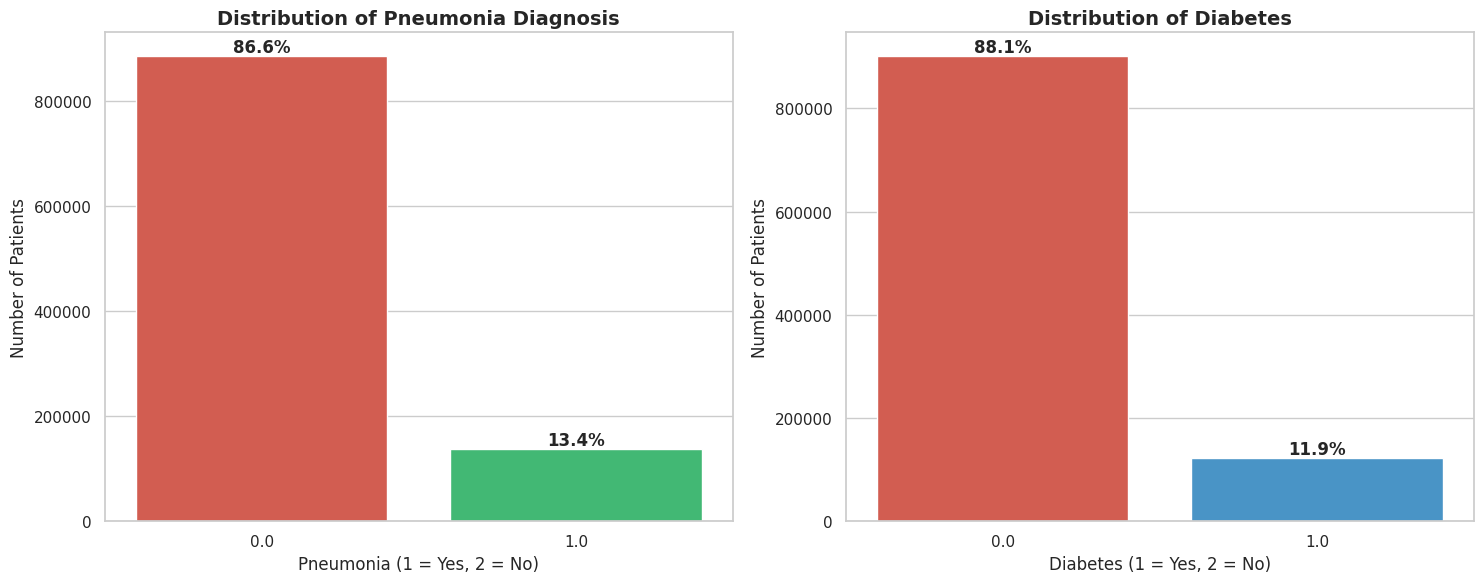

In [7]:
# Set visual style
sns.set_theme(style="whitegrid")

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Plot 1: Pneumonia Distribution ---
# Assuming 1 = Yes, 2 = No
ax1 = sns.countplot(data=df, x='PNEUMONIA', palette=['#E74C3C', '#2ECC71'], ax=axes[0])
axes[0].set_title('Distribution of Pneumonia Diagnosis', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Pneumonia (1 = Yes, 2 = No)', fontsize=12)
axes[0].set_ylabel('Number of Patients', fontsize=12)

# Add percentages
total = len(df)
for p in ax1.patches:
    height = p.get_height()
    percentage = f'{100 * height / total:.1f}%'
    ax1.annotate(percentage, (p.get_x() + p.get_width() / 2., height), 
                 ha='center', va='bottom', fontsize=12, fontweight='bold')

# --- Plot 2: Diabetes Distribution ---
ax2 = sns.countplot(data=df, x='DIABETES', palette=['#E74C3C', '#3498DB'], ax=axes[1])
axes[1].set_title('Distribution of Diabetes', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Diabetes (1 = Yes, 2 = No)', fontsize=12)
axes[1].set_ylabel('Number of Patients', fontsize=12)

# Add percentages
for p in ax2.patches:
    height = p.get_height()
    percentage = f'{100 * height / total:.1f}%'
    ax2.annotate(percentage, (p.get_x() + p.get_width() / 2., height), 
                 ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()